In [2]:
print("Test Env")

Test Env


In [3]:
# ===============================
# 1. Import Libraries
# ===============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

In [4]:
# ===============================
# 2. Load Dataset
# ===============================

df = pd.read_csv("combined_dataset.csv")

df.head()

,project_id,team_id,total_commits,weekly_commits,inactive_days,overdue_tasks,bug_count,high_priority_bugs,task_completion_rate,code_quality_score,collaboration_score,overall_ci_score,progress_percentage,delay_count,risk_status
0,P0556,T019,229,28,25,6,34,4,56,43,38,50,45,4,High Risk
1,MR0492,T076,197,19,6,2,13,2,79,66,58,75,74,3,Medium Risk
2,P0528,T014,290,21,23,1,29,4,42,35,36,70,66,1,Medium Risk
3,MR0926,T082,213,13,8,2,8,1,64,78,67,53,77,2,Medium Risk
4,LR0990,T024,493,43,2,1,7,1,89,83,80,94,80,1,Low Risk


In [5]:
# ===============================
# 3. Basic Dataset Information
# ===============================

print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns)

print("\nDataset Info:")
df.info()

print("\nStatistical Summary:")
df.describe()

Dataset Shape: (4000, 15)

Column Names:
Index(['project_id', 'team_id', 'total_commits', 'weekly_commits',
       'inactive_days', 'overdue_tasks', 'bug_count', 'high_priority_bugs',
       'task_completion_rate', 'code_quality_score', 'collaboration_score',
       'overall_ci_score', 'progress_percentage', 'delay_count',
       'risk_status'],
      dtype='str')

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   project_id            4000 non-null   str  
 1   team_id               4000 non-null   str  
 2   total_commits         4000 non-null   int64
 3   weekly_commits        4000 non-null   int64
 4   inactive_days         4000 non-null   int64
 5   overdue_tasks         4000 non-null   int64
 6   bug_count             4000 non-null   int64
 7   high_priority_bugs    4000 non-null   int64
 8   task_completion_rate  4000 

,total_commits,weekly_commits,inactive_days,overdue_tasks,bug_count,high_priority_bugs,task_completion_rate,code_quality_score,collaboration_score,overall_ci_score,progress_percentage,delay_count
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.00000,4000.00000,4000.000000,4000.000000,4000.000000
mean,258.337500,29.404250,8.249750,4.716750,14.131750,3.192500,69.898000,71.96050,68.33900,68.837750,67.271500,3.231750
std,130.249303,16.291322,7.022799,4.414396,11.083077,2.985745,21.797784,18.47541,21.40318,21.476341,23.759333,2.974686
min,10.000000,1.000000,0.000000,0.000000,0.000000,0.000000,20.000000,30.00000,20.00000,20.000000,10.000000,0.000000
25%,156.000000,16.000000,3.000000,1.000000,5.000000,1.000000,57.000000,59.00000,53.00000,54.000000,52.000000,1.000000
50%,239.000000,26.000000,7.000000,3.000000,11.000000,2.000000,72.000000,74.00000,71.00000,71.000000,72.000000,2.000000
75%,370.000000,43.000000,12.000000,7.000000,20.000000,5.000000,89.000000,87.00000,86.00000,87.000000,86.000000,5.000000
max,500.000000,60.000000,25.000000,15.000000,40.000000,10.000000,100.000000,100.00000,100.00000,100.000000,100.000000,10.000000


In [6]:
# ===============================
# 4. Check Missing Values
# ===============================

missing_values = df.isnull().sum()
print(missing_values)

project_id              0
team_id                 0
total_commits           0
weekly_commits          0
inactive_days           0
overdue_tasks           0
bug_count               0
high_priority_bugs      0
task_completion_rate    0
code_quality_score      0
collaboration_score     0
overall_ci_score        0
progress_percentage     0
delay_count             0
risk_status             0
dtype: int64


In [7]:
# ===============================
# 5. Check Duplicate Records
# ===============================

duplicates = df.duplicated().sum()
print("Duplicate Records:", duplicates)

# Remove duplicates if any
df = df.drop_duplicates()

Duplicate Records: 0


risk_status
High Risk      1458
Medium Risk    1403
Low Risk       1139
Name: count, dtype: int64


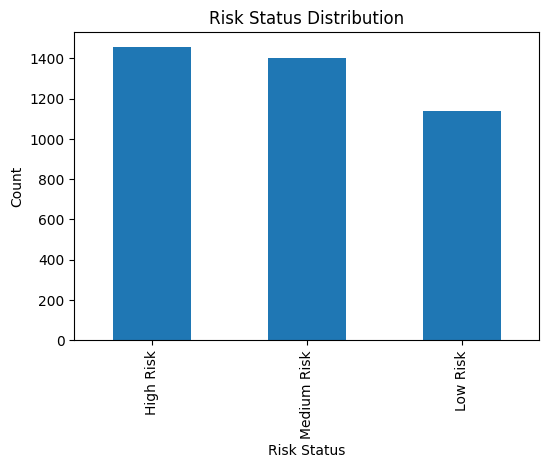

In [8]:
# ===============================
# 6. Target Class Distribution
# ===============================

print(df["risk_status"].value_counts())

plt.figure(figsize=(6,4))
df["risk_status"].value_counts().plot(kind="bar")
plt.title("Risk Status Distribution")
plt.xlabel("Risk Status")
plt.ylabel("Count")
plt.show()

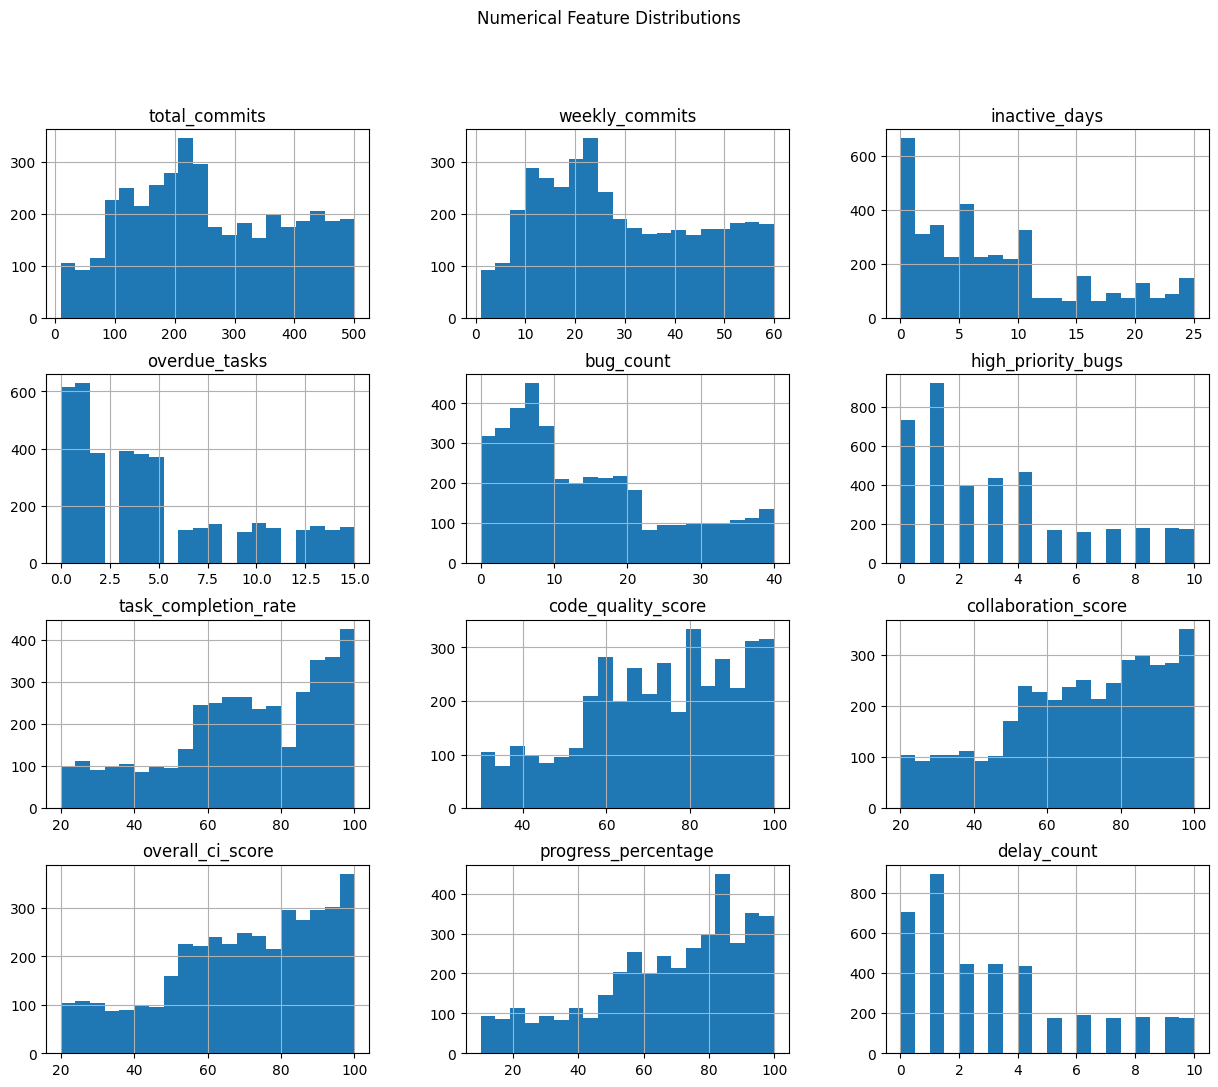

In [9]:
# ===============================
# 7. Numerical Column Analysis
# ===============================

numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

df[numeric_cols].hist(figsize=(15, 12), bins=20)
plt.suptitle("Numerical Feature Distributions")
plt.show()

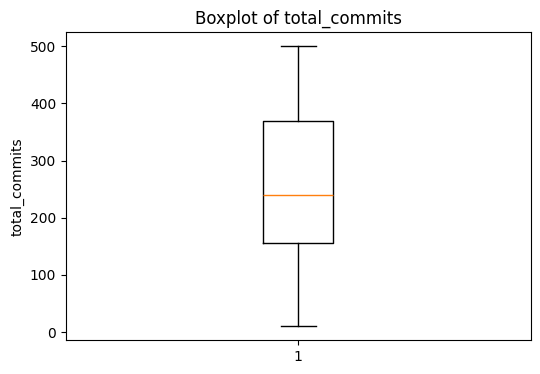

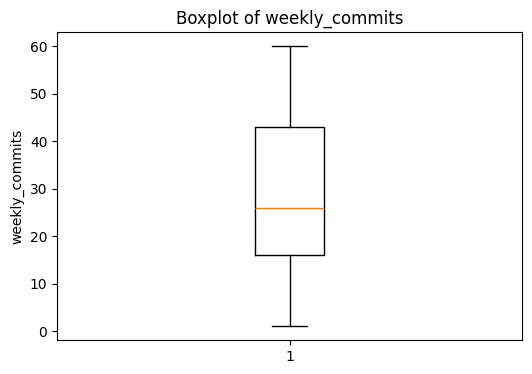

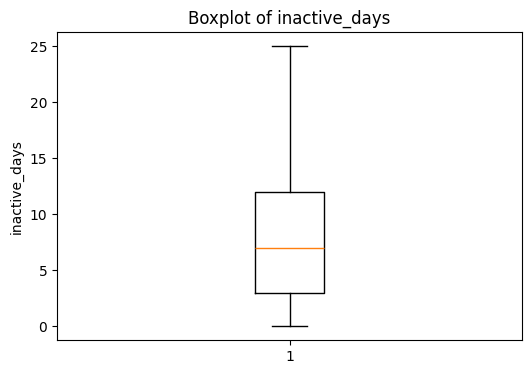

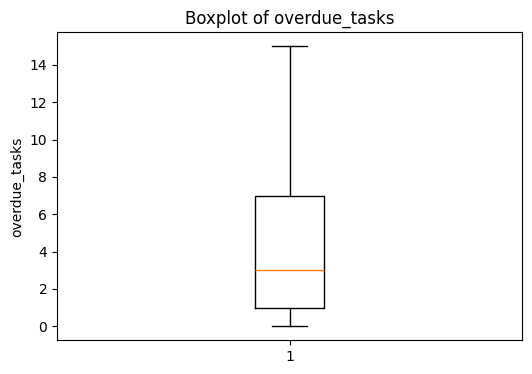

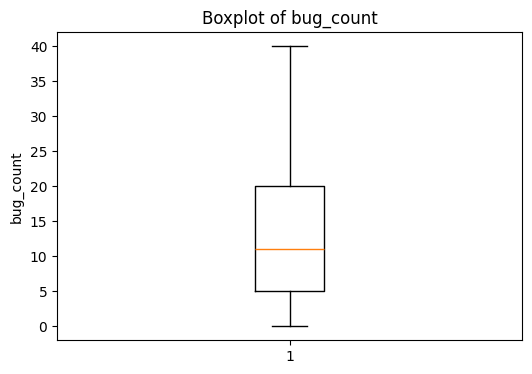

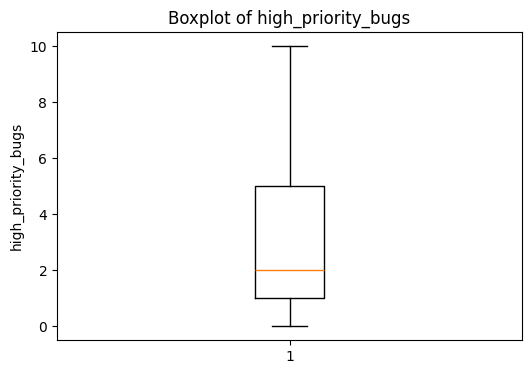

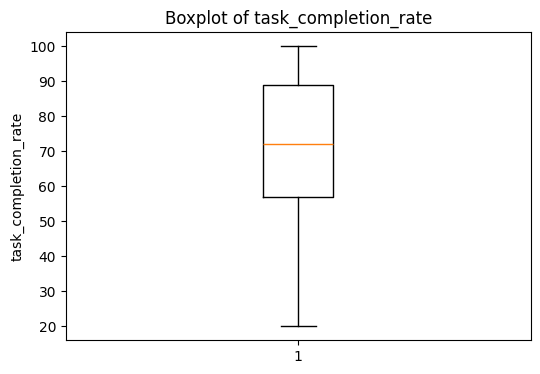

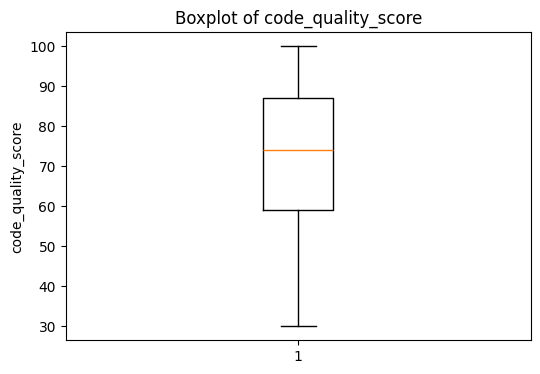

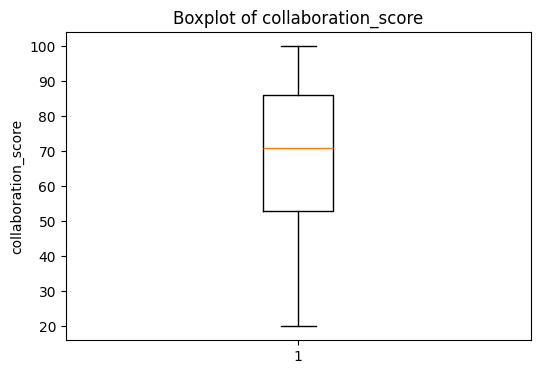

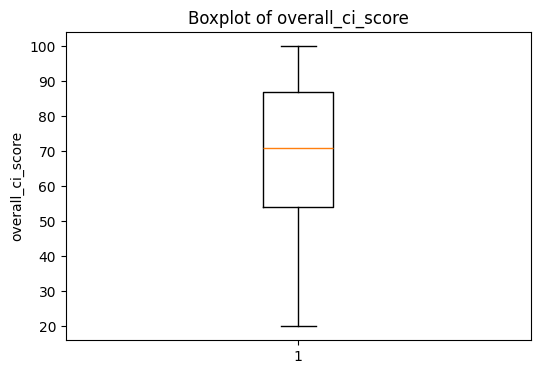

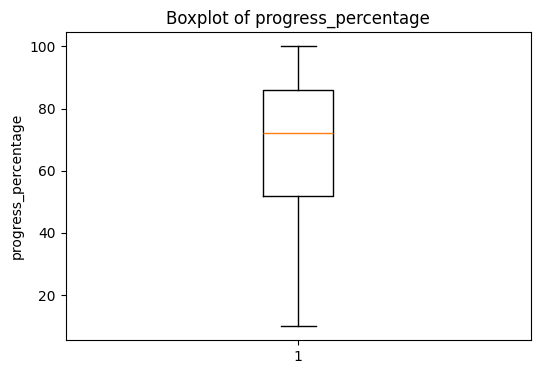

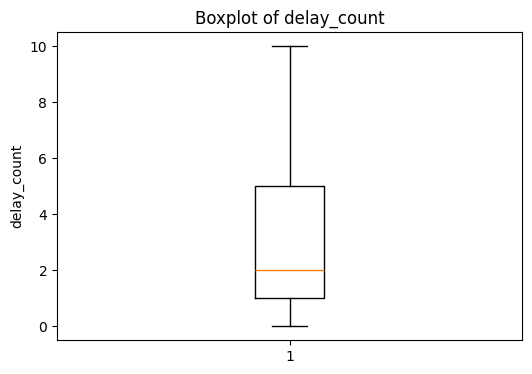

In [10]:
# ===============================
# 8. Boxplots to Check Outliers
# ===============================

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    plt.boxplot(df[col])
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)
    plt.show()

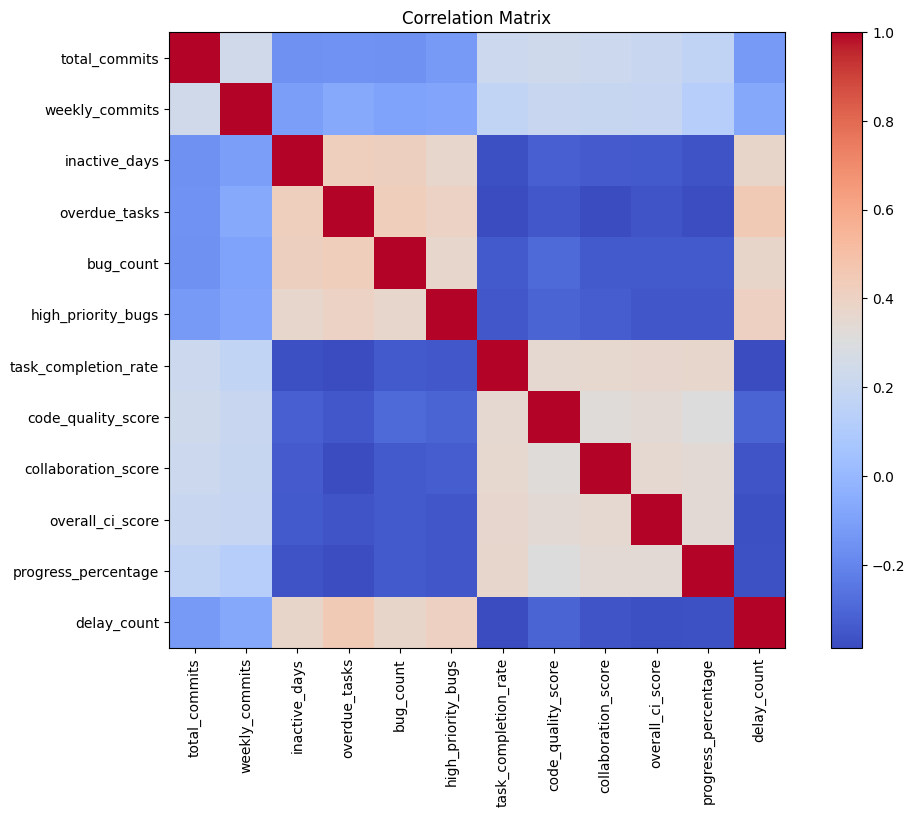

In [11]:
# ===============================
# 9. Correlation Analysis
# ===============================

correlation_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12,8))
plt.imshow(correlation_matrix, cmap="coolwarm", interpolation="nearest")
plt.colorbar()
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=90)
plt.yticks(range(len(numeric_cols)), numeric_cols)
plt.title("Correlation Matrix")
plt.show()

In [12]:
# ===============================
# 10. Drop Unnecessary Columns
# ===============================

df_processed = df.drop(["project_id", "team_id"], axis=1)

df_processed.head()

,total_commits,weekly_commits,inactive_days,overdue_tasks,bug_count,high_priority_bugs,task_completion_rate,code_quality_score,collaboration_score,overall_ci_score,progress_percentage,delay_count,risk_status
0,229,28,25,6,34,4,56,43,38,50,45,4,High Risk
1,197,19,6,2,13,2,79,66,58,75,74,3,Medium Risk
2,290,21,23,1,29,4,42,35,36,70,66,1,Medium Risk
3,213,13,8,2,8,1,64,78,67,53,77,2,Medium Risk
4,493,43,2,1,7,1,89,83,80,94,80,1,Low Risk


In [13]:
# ===============================
# 11. Encode Target Column
# ===============================

label_encoder = LabelEncoder()

df_processed["risk_status"] = label_encoder.fit_transform(df_processed["risk_status"])

print("Encoded Classes:")
for index, label in enumerate(label_encoder.classes_):
    print(index, "=", label)

Encoded Classes:
0 = High Risk
1 = Low Risk
2 = Medium Risk


In [14]:
# ===============================
# 12. Separate Features and Target
# ===============================

X = df_processed.drop("risk_status", axis=1)
y = df_processed["risk_status"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (4000, 12)
Target Shape: (4000,)


In [15]:
# ===============================
# 13. Train-Test Split
# ===============================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (3200, 12)
X_test: (800, 12)
y_train: (3200,)
y_test: (800,)


In [17]:
# ===============================
# 14. Feature Scaling
# ===============================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Preprocessing completed successfully.")

Preprocessing completed successfully.


In [ ]:
# Save the scaler to a file
import joblib

joblib.dump(scaler, "scaler.pkl")
print("Scaler saved successfully as 'scaler.pkl'")

Scaler saved successfully as 'scaler.joblib'


In [16]:
# ===============================
# 15. Final Processed Data Check
# ===============================

print("Training Feature Sample:")
print(X_train.head())

print("\nTraining Target Sample:")
print(y_train.head())

Training Feature Sample:
      total_commits  weekly_commits  inactive_days  overdue_tasks  bug_count  \
3840            205              17              7              2         10   
1340            176              22              6              5          7   
3701            424              34              3              3         16   
455             345              31              2              1          0   
1474            309              30              9              1         30   

      high_priority_bugs  task_completion_rate  code_quality_score  \
3840                   4                    77                  71   
1340                   3                    76                  75   
3701                   4                    43                  46   
455                    0                    92                  80   
1474                   8                    84                  50   

      collaboration_score  overall_ci_score  progress_percentage  delay_c

In [17]:
import joblib

joblib.dump(X_train_scaled, "X_train.pkl")
joblib.dump(X_test_scaled, "X_test.pkl")
joblib.dump(y_train, "y_train.pkl")
joblib.dump(y_test, "y_test.pkl")

print("Datasets saved as PKL files.")

Datasets saved as PKL files.
